# Error models for α + ⁴⁴Ca elastic scattering: a comparison by evidence

TODO: fix intro text

The experimental data we will use are the differential elastic as ratio to the Rutherford scattering cross sections of $^{44}$Ca($\alpha,\alpha$) at 29 MeV from [EXFOR F0567](https://www-nds.iaea.org/exfor/servlet/X4sSearch5?EntryID=150567),
[Oeschler *et al.*, Phys. Rev. Lett. **28**, 694 (1972)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.28.694). Oeschler *et al.* report no uncertainties, so every error model below infers its own.

See also the [`jitr` quickstart series of tutorials](https://beykyle.github.io/jitr/getting-started.html). In a sense, this tutorial is a successor to those: using `rxmc` we can craft more sophisticated statistical models, including using [Gaussian processes for model discrepancy](https://rss.onlinelibrary.wiley.com/doi/abs/10.1111/1467-9868.00294),

Recipes: 10, 11, 13, 18

In [1]:
import corner
import dynesty
import jitr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from jitr.optical_potentials.potential_forms import (
    coulomb_charged_sphere,
    woods_saxon_safe,
)
from scipy import stats
from sklearn.gaussian_process.kernels import Matern

import rxmc as rx
from rxmc import terms as T
from rxmc import transforms as tf

## The data

Every fourth angle of the ⁴⁴Ca set, 73 points from 15° to 174°.  Ratio to
Rutherford is dimensionless, so the dataset needs no unit conversion; the
kinematics the model needs go in `meta`, and there are no errors to report.

73 points between 15 and 174 degrees


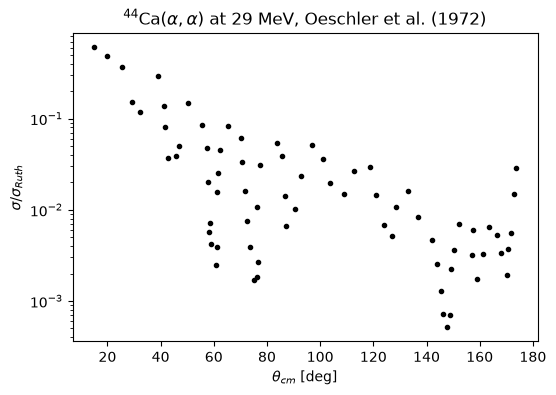

In [2]:
df = pd.read_csv("data/alpha_ca_ratio_ruth.csv")
df = df[df["target"] == "Ca44"].iloc[::4]
reaction = jitr.reactions.ElasticReaction(target=(44, 20), projectile=(4, 2))
E_lab = 29.0
meta = {"reaction": reaction, "Elab": E_lab, "quantity": "dXS/dRuth"}
angles = np.deg2rad(df["angle_cm_deg"].to_numpy())
ratio = df["ratio_to_rutherford"].to_numpy()
data = rx.Dataset(
    angles, ratio, np.zeros(ratio.size), label="44Ca(a,a) 29 MeV", meta=meta
)
print(
    f"{data.n} points between {np.rad2deg(angles.min()):.0f} and {np.rad2deg(angles.max()):.0f} degrees"
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.rad2deg(angles), ratio, "o", ms=3, color="k")
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$\sigma / \sigma_{Ruth}$",
    yscale="log",
    title=r"$^{44}$Ca($\alpha,\alpha$) at 29 MeV, Oeschler et al. (1972)",
)
plt.show()

## The optical model

As in the `jitr` quickstart: a Woods-Saxon potential and the Coulomb
potential of a uniformly charged sphere of radius `1.3 A^{1/3}` fm, radii in
units of `A^{1/3}` fm.  Here the real and imaginary volume terms share one
geometry, so four parameters are free: `V`, `W`, `r`, `a`.  Priors follow
the quickstart's typical α-nucleus values, truncated at zero.  Thirty
partial waves are converged at this energy; the default basis size is
within a few percent of the fully converged solver at the deepest minima,
which is far below the error models below, and two hundred times faster.

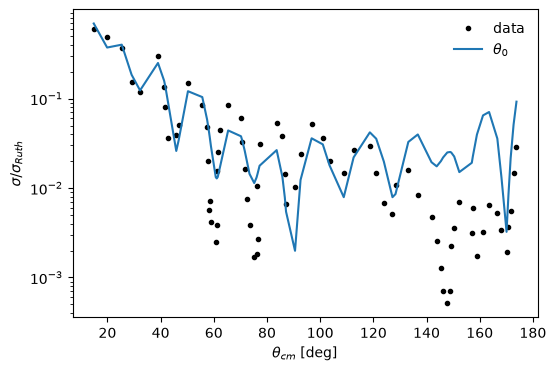

In [3]:
A13 = 44 ** (1 / 3)


def central(r, V, W, R, a):
    return -(V + 1j * W) * woods_saxon_safe(r, R * A13, a)


def coulomb(r):
    return coulomb_charged_sphere(
        r, reaction.target.Z * reaction.projectile.Z, 1.3 * A13
    )


params = [
    rx.Parameter("V", prior=stats.norm(150.0, 20.0), bounds=(0.0, np.inf), latex="V"),
    rx.Parameter("W", prior=stats.norm(20.0, 10.0), bounds=(0.0, np.inf), latex="W"),
    rx.Parameter("r", prior=stats.norm(1.4, 0.3), bounds=(0.8, 2.0), latex="r"),
    rx.Parameter("a", prior=stats.norm(0.5, 0.2), bounds=(0.2, 1.0), latex="a"),
]
omp = rx.reactions.ElasticXS(
    "dXS/dRuth",
    central,
    lambda r: 0.0 * r,
    lambda ws, *x: (tuple(x), (), ()),
    params,
    coulomb=coulomb,
    lmax=30,
)
theta_0 = np.array([150.0, 20.0, 1.4, 0.5])
on_data = omp.bind(angles, meta)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.rad2deg(angles), ratio, "o", ms=3, color="k", label="data")
ax.plot(np.rad2deg(angles), on_data(*theta_0), color="C0", label=r"$\theta_0$")
ax.set(xlabel=r"$\theta_{cm}$ [deg]", ylabel=r"$\sigma / \sigma_{Ruth}$", yscale="log")
ax.legend(frameon=False)
plt.show()

## The error-model ladder

Data spanning three decades with unreported, presumably multiplicative,
errors are compared in log space (recipe 10): `space=tf.log` transforms the
data once and every prediction, and `problem.log_jacobian()` is what makes a
log-space evidence comparable with a linear-space one.  With no reported
errors every rung uses `statistical=False`: the inferred terms *are* the
covariance.

| label | error model |
|---|---|
| `L0` | constant noise in log space, `σ = ε` on every point |
| `E0` | fractional noise in linear space, `σ_i = ε ym_i` |
| `L2y` | `L0` plus a free normalisation mode, `η ym` (the `jitr` calibration notebook's error model) |
| `Lgp` | `L0` plus a Matérn(5/2) Gaussian process in `u = θ/π` with a free amplitude |

The same `log_eps` object is reused across rungs; each `Problem` compiles
independently (recipe 18).  Priors (recipe 13): log-uniform on the error
scales between 5 % and 200 %, as in the `jitr` notebook.

In [4]:
comp_log = rx.Comparison(data, omp, space=tf.log)
comp_lin = rx.Comparison(data, omp)
log_eps = rx.Parameter(
    "log_eps",
    prior=stats.uniform(np.log(0.05), np.log(2.0) - np.log(0.05)),
    latex=r"\log\epsilon",
)
log_eta = rx.Parameter(
    "log_eta",
    prior=stats.uniform(np.log(0.05), np.log(2.0) - np.log(0.05)),
    latex=r"\log\eta",
)
log_amp = rx.Parameter(
    "log_A",
    prior=stats.uniform(np.log(0.05), np.log(2.0) - np.log(0.05)),
    latex=r"\log A",
)
log_ell = rx.Parameter(
    "log_ell",
    prior=stats.uniform(np.log(0.02), np.log(1.0) - np.log(0.02)),
    latex=r"\log\ell",
)
gp = T.kernel(
    Matern(0.1, nu=2.5),
    on=comp_log,
    coords=lambda x: x / np.pi,
    amplitude=T.constant_amplitude,
    amplitude_params=(log_amp,),
    params=[log_ell],
)
ladder = {
    "L0": rx.Constraint([comp_log], terms=[T.noise(log_eps)], statistical=False),
    "E0": rx.Constraint(
        [comp_lin], terms=[T.noise_fraction(log_eps)], statistical=False
    ),
    "L2y": rx.Constraint(
        [comp_log],
        terms=[T.noise(log_eps), T.normalization(log_eta)],
        statistical=False,
    ),
    "Lgp": rx.Constraint([comp_log], terms=[T.noise(log_eps), gp], statistical=False),
}
problems = {name: rx.Problem([c]) for name, c in ladder.items()}
for name, p in problems.items():
    print(f"{name:4s} columns: {p.names}")

L0   columns: ['V', 'W', 'r', 'a', 'log_eps']
E0   columns: ['V', 'W', 'r', 'a', 'log_eps']
L2y  columns: ['V', 'W', 'r', 'a', 'log_eps', 'log_eta']
Lgp  columns: ['V', 'W', 'r', 'a', 'log_eps', 'log_ell', 'log_A']


In [5]:
def fit_nested(problem, seed, nlive=80, dlogz=1.5):
    sampler = dynesty.NestedSampler(
        problem.log_likelihood,
        problem.prior_transform,
        problem.ndim,
        nlive=nlive,
        sample="rwalk",
        rstate=np.random.default_rng(seed),
    )
    sampler.run_nested(dlogz=dlogz, print_progress=False)
    return sampler.results


results, samples = {}, {}
for i, (name, p) in enumerate(problems.items()):
    res = fit_nested(p, seed=i)
    results[name] = res
    samples[name] = res.samples_equal(rstate=np.random.default_rng(i))
    print(
        f"{name:4s} log Z = {res.logz[-1]:8.2f} +/- {res.logzerr[-1]:.2f}   {int(np.sum(res.ncall)):6d} calls"
    )

L0   log Z =  -101.42 +/- 0.95    26153 calls


E0   log Z =   211.36 +/- 1.03    34980 calls


L2y  log Z =   -98.22 +/- 0.85    22672 calls


Lgp  log Z =   -92.18 +/- 0.95    30383 calls


## Evidence, comparable across spaces

`logz_summary` records the sampler's error; adding `problem.log_jacobian()`
to a log-space evidence puts it in the same units as a linear-space one, so
`E0` can be compared with the others.  `compare_logz` returns a verdict
that is a tie unless the difference exceeds twice the combined error.

In [6]:
logz = {
    name: rx.diagnostics.logz_summary(
        results[name].logz[-1] + problems[name].log_jacobian(),
        results[name].logzerr[-1],
    )
    for name in problems
}
print(f"{'rung':5s} {'log Z (linear-space units)':>28s}")
for name, (mean, err, _) in logz.items():
    print(f"{name:5s} {mean:20.2f} +/- {err:.2f}")
best = max(logz, key=lambda n: logz[n][0])
print(f"\nbest rung: {best}")
for name in problems:
    if name != best:
        v = rx.diagnostics.compare_logz(logz[best], logz[name])
        print(
            f"{best} vs {name}: dlogZ = {v['dlogZ']:6.2f} +/- {v['err']:.2f}  ->  {v['verdict']}"
        )

rung    log Z (linear-space units)
L0                  213.05 +/- 0.95
E0                  211.36 +/- 1.03
L2y                 216.26 +/- 0.85
Lgp                 222.30 +/- 0.95

best rung: Lgp
Lgp vs L0: dlogZ =   9.24 +/- 1.34  ->  a
Lgp vs E0: dlogZ =  10.93 +/- 1.41  ->  a
Lgp vs L2y: dlogZ =   6.04 +/- 1.28  ->  a


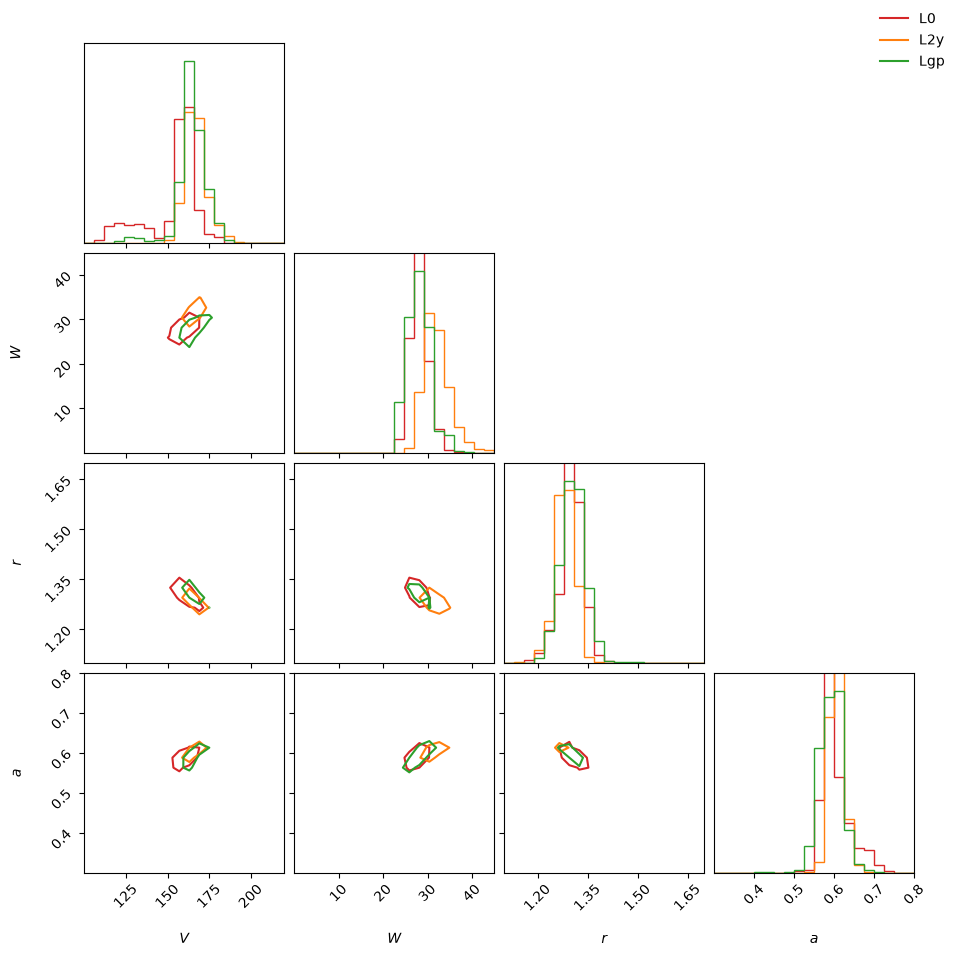

In [7]:
labels = [f"${q.latex}$" for q in params]
fig = None
for name, color in (("L0", "C3"), ("L2y", "C1"), ("Lgp", "C2")):
    fig = corner.corner(
        samples[name][:, problems[name].columns(params)],
        fig=fig,
        color=color,
        labels=labels,
        plot_datapoints=False,
        plot_density=False,
        levels=(0.68,),
        range=[(100, 220), (0, 45), (1.1, 1.7), (0.3, 0.8)],
    )
fig.legend(
    handles=[
        plt.Line2D([], [], color=c, label=n)
        for n, c in (("L0", "C3"), ("L2y", "C1"), ("Lgp", "C2"))
    ],
    loc="upper right",
    frameon=False,
)
plt.show()

## Hold out the backward angles (recipe 11)

Fit each rung below 90° and score the points above it: `masked_where` keeps
every object, `complement()` flips the mask, and a chain from the fit scores
the held-out problem directly.  The joint held-out log predictive is a
different question from the evidence: not "which model explains the fitted
data" but "which model predicts what it has not seen".

The normalisation of `L2y` and the Gaussian process of `Lgp` both couple the
angles we fit to the ones we hold out, so the honest score is not the marginal
density of the held-out points but the conditional
$p(y_\mathrm{held} \mid y_\mathrm{fit}, \theta)$: passing `given=p_fit` to
both diagnostics computes exactly that (recipe 11).  For `L0` nothing couples
the two, and the conditional is the marginal.

In [8]:
cut = np.deg2rad(90.0)
scores = {}
for i, (name, c) in enumerate(ladder.items()):
    if name == "E0":
        continue  # same space as L0 up to the noise model; the log-space rungs are the comparison here
    fit = c.masked_where(lambda x: x < cut)
    p_fit, p_held = rx.Problem([fit]), rx.Problem([fit.complement()])
    res = fit_nested(p_fit, seed=10 + i)
    s = res.samples_equal(rstate=np.random.default_rng(10 + i))
    lp = rx.diagnostics.heldout_log_predictive(p_held, s[::5], given=p_fit)
    draws = rx.diagnostics.predictive_draws(
        p_held, s[::20], n_rep=2, rng=i, given=p_fit
    )
    h = p_held.constraints[0]
    cov68 = rx.diagnostics.coverage_curve(draws, h.y[h.active], [0.68])[0]
    scores[name] = (
        rx.diagnostics.log_posterior_predictive(lp),
        cov68,
        s,
        p_fit,
        p_held,
    )
    print(
        f"{name:4s} held-out log predictive = {scores[name][0]:8.2f}   68 % coverage of the held-out points = {cov68:.2f}"
    )

L0   held-out log predictive =   -60.50   68 % coverage of the held-out points = 0.49


L2y  held-out log predictive =   -55.34   68 % coverage of the held-out points = 0.60


Lgp  held-out log predictive =   -50.45   68 % coverage of the held-out points = 0.80


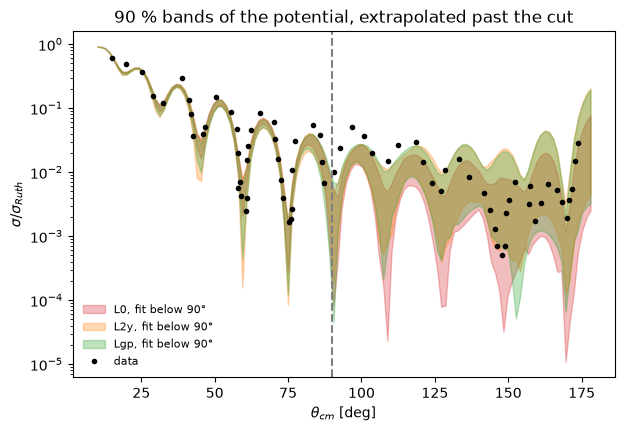

In [9]:
x_fine = np.deg2rad(np.linspace(10.0, 178.0, 120))
on_fine = omp.bind(x_fine, meta)
fig, ax = plt.subplots(figsize=(7, 4.5))
for name, color in (("L0", "C3"), ("L2y", "C1"), ("Lgp", "C2")):
    _, _, s, p_fit, _ = scores[name]
    curves = np.array([on_fine(*row[p_fit.columns(params)]) for row in s[::25]])
    lo, hi = np.percentile(curves, [5, 95], axis=0)
    ax.fill_between(
        np.rad2deg(x_fine),
        lo,
        hi,
        color=color,
        alpha=0.3,
        label=f"{name}, fit below 90°",
    )
ax.plot(np.rad2deg(angles), ratio, "o", ms=3, color="k", label="data")
ax.axvline(90.0, color="0.5", ls="--")
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$\sigma / \sigma_{Ruth}$",
    yscale="log",
    title="90 % bands of the potential, extrapolated past the cut",
)
ax.legend(frameon=False, fontsize=8)
plt.show()

## Takeaways

- One comparison, one potential, four covariances: the ladder is a
  dictionary of constraints, and every problem compiles on its own.
- Log space is where multiplicative errors are additive; the Jacobian makes
  its evidence comparable with a linear-space fit.
- Evidence and held-out prediction ask different questions.  Here the GP
  rung wins both.  Scored honestly, conditioned on the forward angles, the
  normalisation rung's intervals are too narrow at the backward angles (60 %
  of the held-out points fall inside the nominal 68 % band) and the GP
  rung's are too wide (80 %): neither is calibrated past the cut, and a
  rung that explains the forward angles best need not predict the backward
  ones.
- Light-ion potentials are famously ambiguous: several parameter families
  give nearly the same cross section.  The `L0` posterior above carries a
  second family near `V ≈ 125` MeV beside the main one at `V ≈ 165` MeV,
  and it is the prior, not the data, that decides how much weight each
  gets (see the `jitr` calibration notebook on the discrete ambiguity).